# Traffic Distribution (Task 2-I)
Compute the PDF of total two-month traffic per square (10,000 areas).

In [1]:
# Imports and path setup
from pathlib import Path
import sys
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "src").is_dir()), None)
if project_root is None:
    raise RuntimeError("Could not locate project root with 'src' directory")
sys.path.insert(0, str(project_root))

from src.utils.config import get_config
from src.analysis.eda import traffic_pdf_sample
from src.visualization.plots import plot_pdf

cfg = get_config()

In [2]:
# Load parquet from Task 1
parquet_path = cfg.data_processed / "city_traffic.parquet"
city_df = pd.read_parquet(parquet_path)
city_df.head()

,square_id,time_interval,internet_traffic
0,1,2013-10-31 23:00:00+00:00,11.028366
1,1,2013-10-31 23:10:00+00:00,11.127101
2,1,2013-10-31 23:20:00+00:00,10.892771
3,1,2013-10-31 23:30:00+00:00,8.622424
4,1,2013-10-31 23:40:00+00:00,8.009928


In [3]:
# Total traffic per square
total_per_square = traffic_pdf_sample(city_df)
total_per_square.describe()

count     10000.000000
mean      24697.943359
std       36427.191406
min          70.259644
25%        5131.139160
50%       12850.705566
75%       27518.409668
max      750987.937500
Name: internet_traffic, dtype: float64

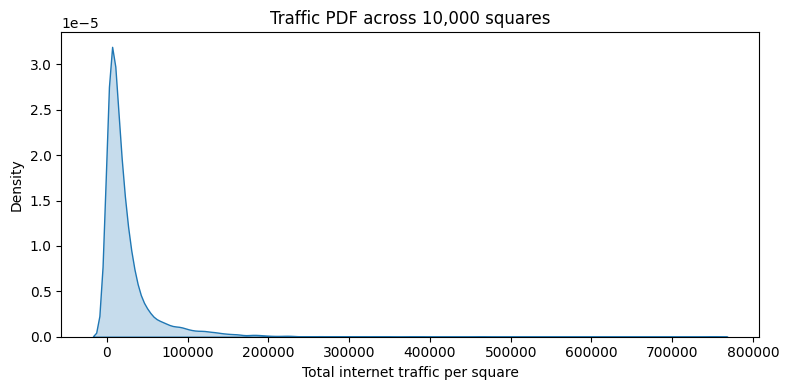

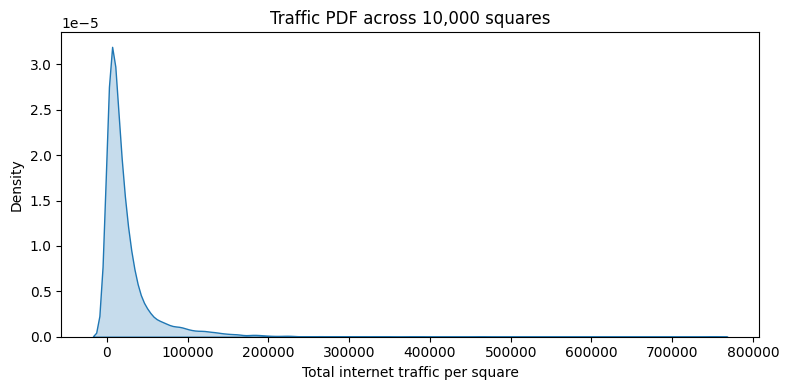

In [4]:
# PDF plot
fig, ax = plot_pdf(total_per_square, title="Traffic PDF across 10,000 squares")
fig